# Installer et importer seaborn, matplotlib, pandas, numpy

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

In [5]:
import numpy as np

# Importer mesures_capteurs.csv dans le dataframe df

In [6]:
df= pd.read_csv("../data/mesures_capteurs.csv")

In [7]:
print (df)

    id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0       M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1       M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2       M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3       M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4       M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   
..        ...                  ...        ...      ...          ...       ...   
600     M0072  2026-01-07 23:00:00       C012     B004        23.67     60.28   
601     M0107  2026-01-09 10:00:00       C011     B004        24.34     61.42   
602     M0271  2026-01-16 06:00:00       C007     B003        23.73     63.49   
603     M0436  2026-01-23 03:00:00       C004     B002        24.83     79.77   
604     M0103  2026-01-09 06:00:00       C007     B003        17.02     52.04   

     pression  consommation

# Partie 1: Distribution d'une variable avec histplot()

## 1) Afficher la distribution des températures 

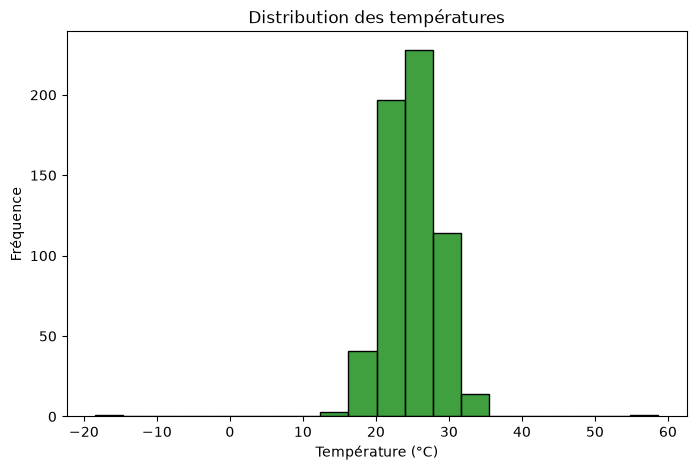

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="temperature", bins=20, color= "green")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

## 2) Autour de quelle valeur les températures sont concentrées ? 

Après lecture de cette histogramme, on consate que les valeurs sont regroupées entre environ 24 et 30°c où la fréquence d'apparution des valeurs approche les 250.

## 3) La distribution semble-t-elle symétrique ? 

Cette première représentation de la température montre une asymétrie légère au niveau de la distribution avec de part et d'autre du pic de l'histogramme avec une descente rapide au niveau du coté droit. La cloche n'est pa sparfaitement équilibrée mais l'écart reste modeste.

## 4) Existe-t-il des valeurs extrêmes ?

On note la présence de valeurs eloignées au niveau du graphique qui s'écarte du point de concentration des valeurs. En effet à gauche, sur l'intervalle -18°c et -15° c et à droite sur l'intervalle 55-60° c on note des veleurs très valeurs très éloignées bien que leur fréquence d'apparution sur le graphique est faible.

## 5) Modifier le nombre de classes 

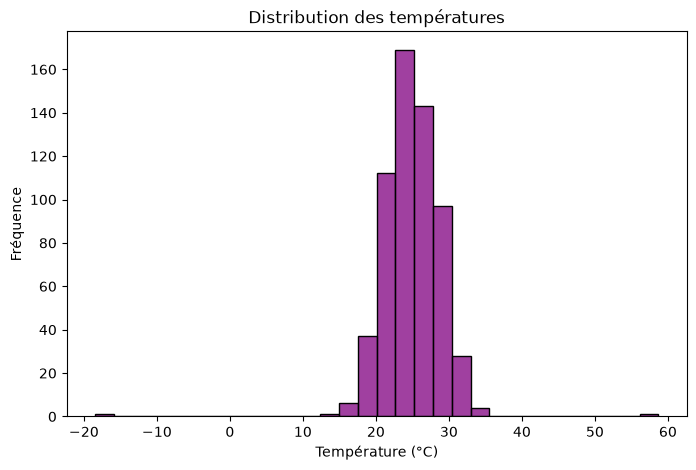

In [9]:
# Modification à 30 bins

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="temperature", bins=30, color= "purple")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

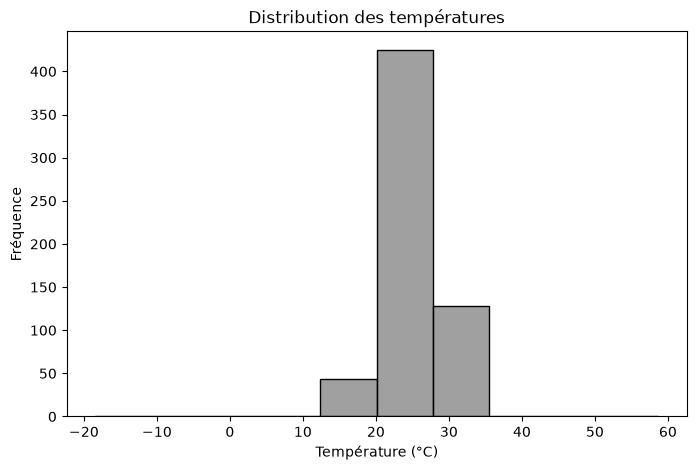

In [10]:
# Modification à 10 bins

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="temperature", bins=10, color= "grey")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

## 6) Afficher la distribution des températures par bâtiment

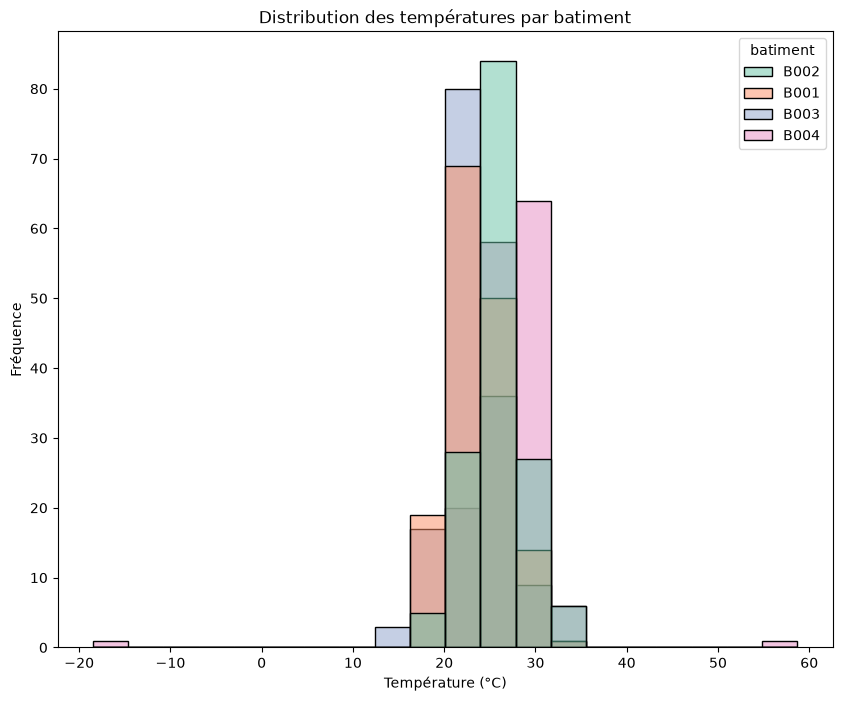

In [11]:
# Imporation des palettes de couleurs
sns.color_palette("viridis")
plt.figure(figsize=(10,8))
sns.histplot(data=df, x="temperature", bins=20, palette= "Set2", hue= "batiment")
plt.title("Distribution des températures par batiment")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

# Partie 2:  Distribution d'une variable avec kdeplot() 

## 1) Afficher la distribution des températures

<function matplotlib.pyplot.show(close=None, block=None)>

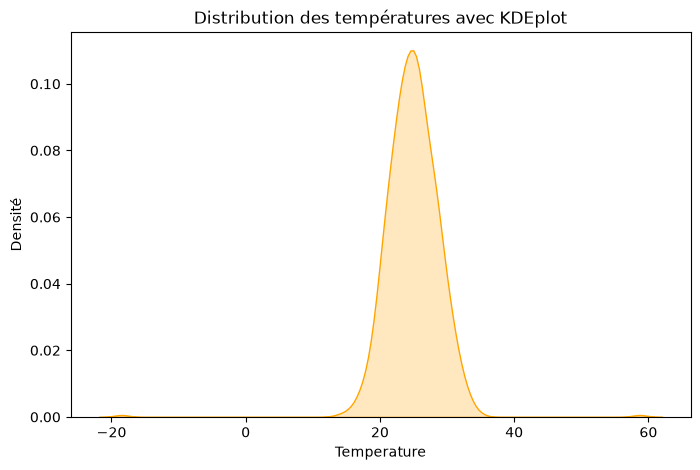

In [12]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x= "temperature", fill= True, color="orange")
plt.title("Distribution des températures avec KDEplot")
plt.xlabel("Temperature")
plt.ylabel("Densité")
plt.show

## 2) Afficher la distribution des températures par bâtiment

<function matplotlib.pyplot.show(close=None, block=None)>

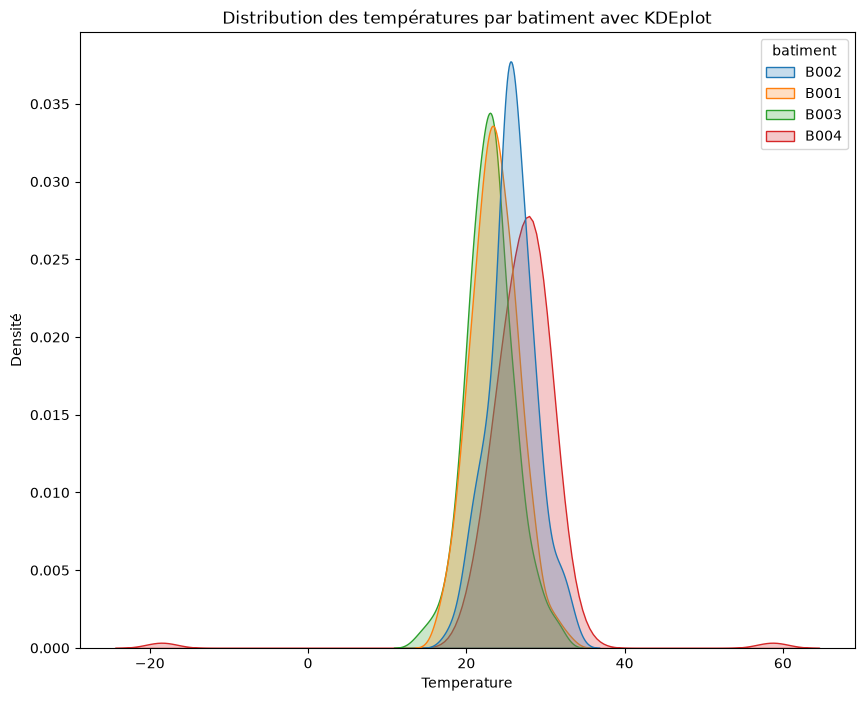

In [13]:
plt.figure(figsize=(10,8))
sns.kdeplot(data=df, x= "temperature", fill= True, color="orange", hue= "batiment")
plt.title("Distribution des températures par batiment avec KDEplot")
plt.xlabel("Temperature")
plt.ylabel("Densité")
plt.show

# Partie 3: Distribution d'une variable avec boxplot

## 1) Afficher la distribution des températures

<function matplotlib.pyplot.show(close=None, block=None)>

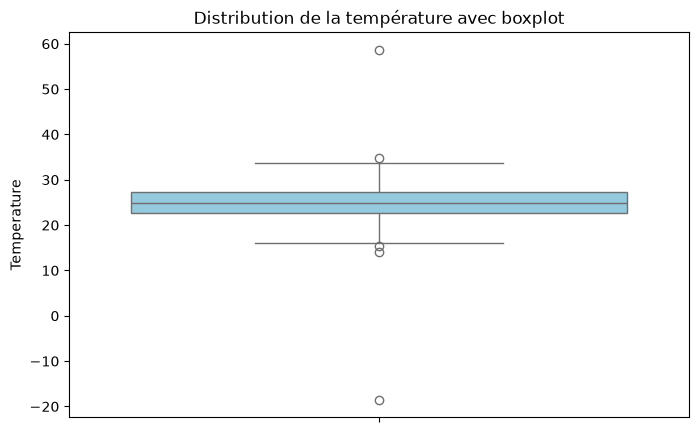

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y="temperature", color="skyblue")
plt.title("Distribution de la température avec boxplot")
plt.ylabel("Temperature")
plt.show

## 2) Afficher la distribution des températures par batiment

<function matplotlib.pyplot.show(close=None, block=None)>

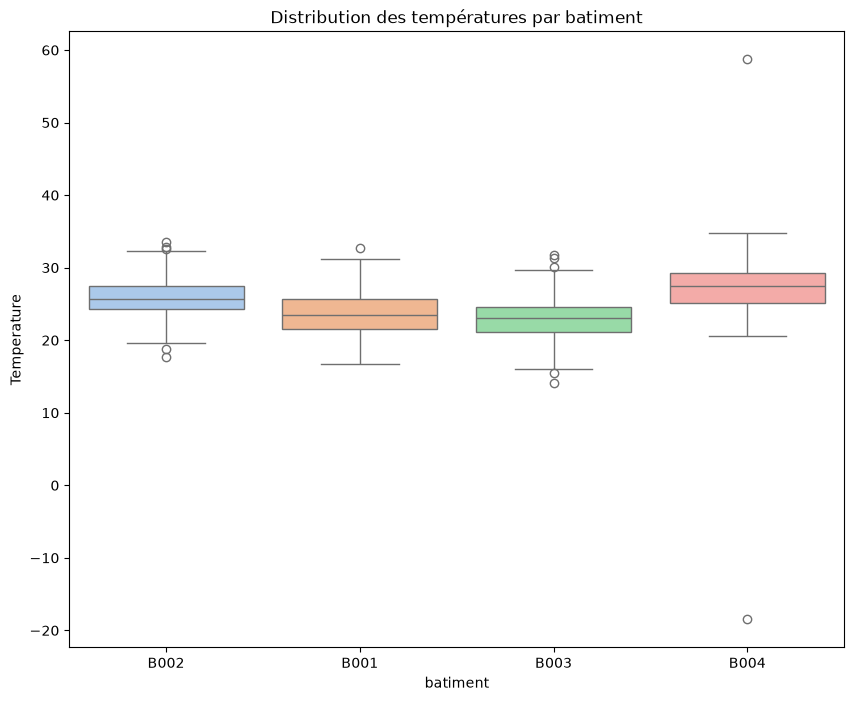

In [15]:
sns.color_palette("viridis")
plt.figure(figsize=(10,8))
sns.boxplot(data=df, y="temperature", x= "batiment", hue ="batiment", palette= "pastel")
plt.title("Distribution des températures par batiment")
plt.ylabel("Temperature")
plt.show

## 3) Pour chaque batiment, quel est la médiane?

In [16]:
medianes = df.groupby("batiment")["temperature"].median()
print("Médianes par bâtiment :\n", medianes)

Médianes par bâtiment :
 batiment
B001    23.540
B002    25.670
B003    23.045
B004    27.535
Name: temperature, dtype: float64


## 3) Pour chaque batiment, quel est la dispersion?

In [17]:
# La dispersion fait allusion à l'écart entre les quartiles Q3 et Q1. Ainsi, le calcul de la dispersion nécessite d'avoir ces deux paramètres.
# Comme que nous utilisons des versions de python et de pandas incompatible, nous contournons le problème avec .agg (aggrégation)
q1= df.groupby("batiment")["temperature"].agg(lambda x: x.quantile(0.25))
print("Le premier quartile par batiment est de: ", q1)
q3= df.groupby("batiment")["temperature"].agg(lambda x: x.quantile(0.75))
print("Le troisième quartile par batiment est de: ", q3)

#La dispersion ou iqr revient à faire la différence entre le q3 et le q1
iqr= q3-q1
print("La dispersion de la temperature pour chaque batiment est de: ", iqr)


Le premier quartile par batiment est de:  batiment
B001    21.6100
B002    24.2675
B003    21.0825
B004    25.1750
Name: temperature, dtype: float64
Le troisième quartile par batiment est de:  batiment
B001    25.6700
B002    27.5300
B003    24.5950
B004    29.2825
Name: temperature, dtype: float64
La dispersion de la temperature pour chaque batiment est de:  batiment
B001    4.0600
B002    3.2625
B003    3.5125
B004    4.1075
Name: temperature, dtype: float64


## Pour chaque batiment, quels sont les valeurs extremes?

In [18]:
def get_outliers(groupe):
    q1 = groupe.quantile(0.25)
    q3 = groupe.quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr
    return groupe[(groupe < borne_basse) | (groupe > borne_haute)]

outliers_par_batiment = df.groupby("batiment")["temperature"].apply(get_outliers)
print("\nValeurs extrêmes par bâtiment :\n", outliers_par_batiment)


Valeurs extrêmes par bâtiment :
 batiment     
B001      520    32.72
B002      118    32.90
          129    33.60
          213    18.85
          438    32.56
          506    17.67
B003      174    31.74
          243    30.16
          245    14.11
          258    15.49
          280    31.30
B004      487   -18.50
          502    58.70
Name: temperature, dtype: float64


## 4) quels bâtiments ont les valeurs les plus extrêmes ? 

In [19]:
nb_outliers = outliers_par_batiment.groupby(level=0).count()
print(nb_outliers)
print("Classement des batiments avec le plus de valeurs extremes: \n", nb_outliers.sort_values(ascending=False))

batiment
B001    1
B002    5
B003    5
B004    2
Name: temperature, dtype: int64
Classement des batiments avec le plus de valeurs extremes: 
 batiment
B002    5
B003    5
B004    2
B001    1
Name: temperature, dtype: int64


# Partie 4 – Distribution d'une variable avec violinplot()

## 1) Afficher la distribution des températures

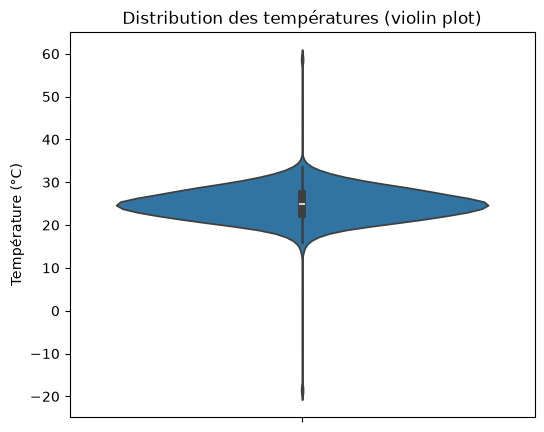

In [20]:
plt.figure(figsize=(6,5))
sns.violinplot(data=df, y="temperature")
plt.title("Distribution des températures (violin plot)")
plt.ylabel("Température (°C)")
plt.show()

## 2) Afficher la distribution des températures par bâtiment

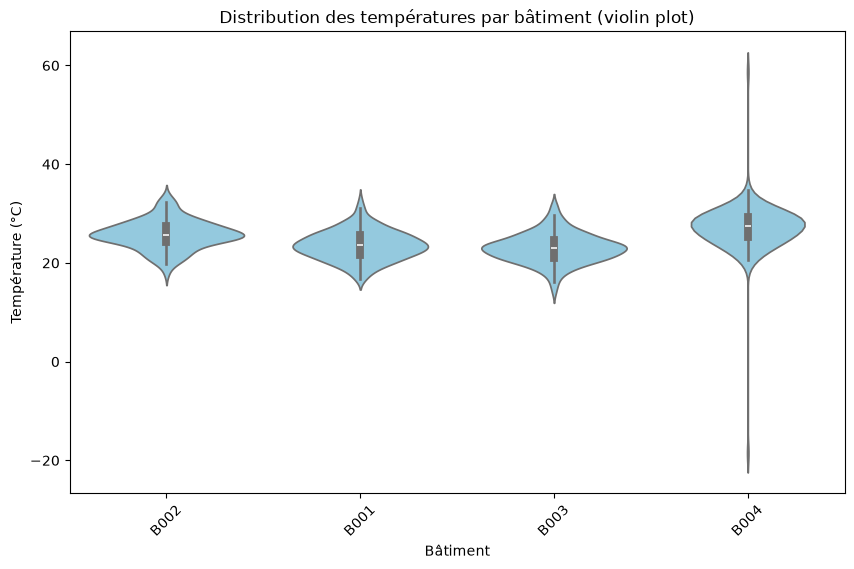

In [22]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="batiment", y="temperature",color= "skyblue" )
plt.title("Distribution des températures par bâtiment (violin plot)")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.xticks(rotation=45)
plt.show()

## 3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot ? 

Le boxplot résume une distribution avec seulement 5 valeurs clés (min, Q1, médiane, Q3, max/outliers).Il ne montre pas la forme réelle de la distribution entre ces points.
Le violin plot révèle la densité complète : par exemple, il peut montrer qu'une distribution est bimodale (deux pics, deux "bourrelets" dans le violon), chose totalement invisible sur un boxplot classique, qui afficherait juste une boîte centrale sans distinguer les deux sous-groupes de valeurs.
Il montre aussi si les valeurs sont concentrées de façon inégale à l'intérieur d'un même quartile (par exemple, beaucoup de valeurs juste au-dessus de Q1 et très peu juste en dessous de la médiane). Le boxplot donnerait l'impression d'une répartition uniforme dans la boîte, ce qui n'est pas forcément le cas.

# Partie 5 – Comptage des catégories avec countplot() 

## 1) Afficher le nombre de mesures par état  

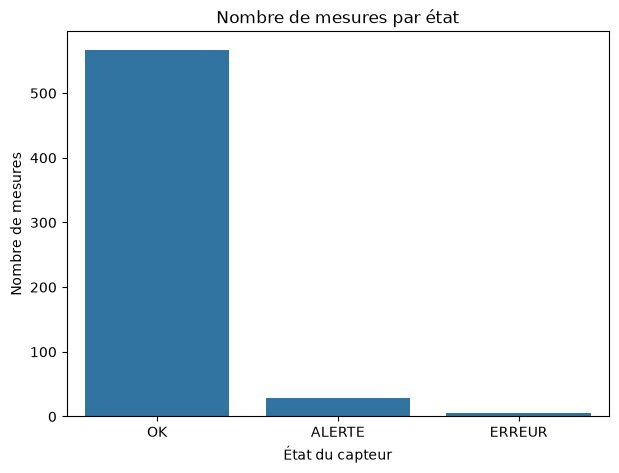

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="etat")
plt.title("Nombre de mesures par état")
plt.xlabel("État du capteur")
plt.ylabel("Nombre de mesures")
plt.show()

## 2) Afficher le nombre de mesures par bâtiment  

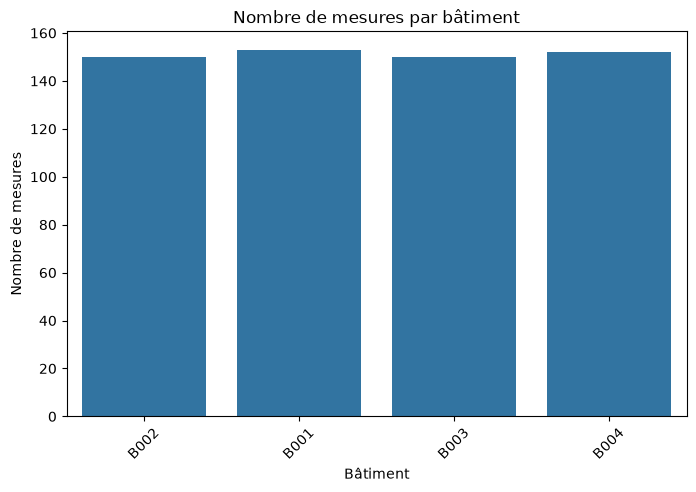

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="batiment")
plt.title("Nombre de mesures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.xticks(rotation=45)
plt.show()

## 3) Afficher les états des capteurs par bâtiment pour identifier

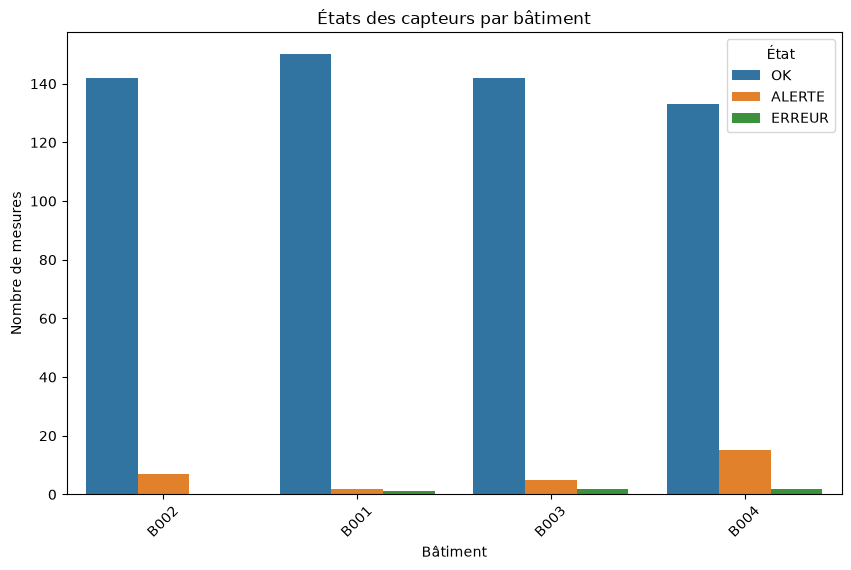

In [26]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="batiment", hue="etat")
plt.title("États des capteurs par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.xticks(rotation=45)
plt.legend(title="État")
plt.show()

**a) Bâtiment avec le plus de mesures en état OK**
→ La barre bleue la plus haute est celle de B001, qui atteint environ 150 mesures, légèrement devant B002 et B003 (environ 142 chacun), et devant B004 (environ 133, la plus basse des quatre).

**b) Bâtiment avec le plus de mesures en ALERTE**
→ La barre orange la plus haute est nettement celle de B004, avec environ 15 mesures en alerte, bien au-dessus des autres bâtiments (B002 ≈ 7, B003 ≈ 5, B001 ≈ 2).

**c) Bâtiment avec le plus de mesures en ERREUR**
→ Les barres vertes sont très petites et proches en hauteur entre B003 et B004 (environ 2 chacun), avec B001 juste en dessous (environ 1), et B002 semble n'avoir aucune mesure en erreur (barre verte invisible/nulle). À l'œil, il est difficile de départager B003 et B004 avec certitude — c'est le genre de cas où mieux vaut vérifier avec les chiffres exacts plutôt que la lecture visuelle seule.

Ce qui ressort clairement de ce graphique : B004 est le bâtiment le plus problématique. Il a le moins de mesures OK (133) ET le plus d'ALERTE (15), un signal cohérent de fonctionnement dégradé. 

À l'inverse, B002 semble le plus fiable en apparence (aucune erreur visible), même s'il a un peu plus d'alertes que B001 et B003.

# Partie 6 – Relation entre deux variables avec scatterplot()

## 1) Etudier graphiquement la relation entre température et consommation 

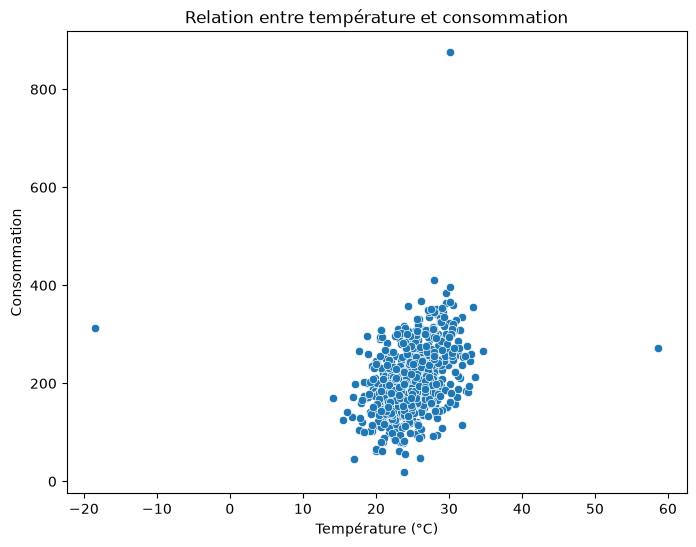

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="temperature", y="consommation")
plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()

## 2) Etudier graphiquement la relation entre température et consommation par bâtiment

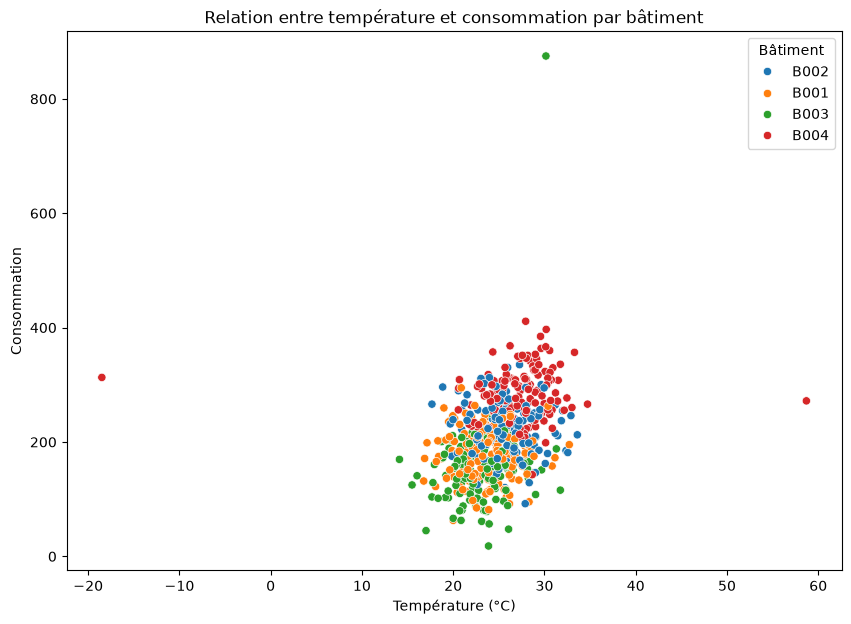

In [30]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment")
plt.title("Relation entre température et consommation par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.legend(title="Bâtiment")
plt.show()

## 3) Modifier la taille des points 

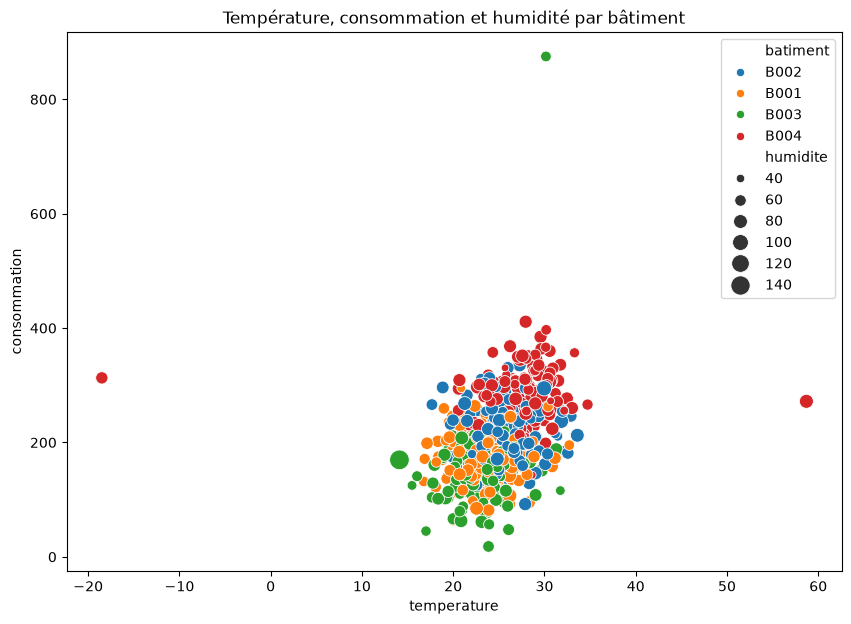

In [31]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", size="humidite", sizes=(20,200))
plt.title("Température, consommation et humidité par bâtiment")
plt.show()
# size="humidite" fait varier la taille des points selon le taux d'humidité, et sizes=(20,200) définit la plage de tailles (en pixels) à utiliser

# Partie 7 – Régression avec regplot() 

Etudier graphiquement une tendance entre température et consommation

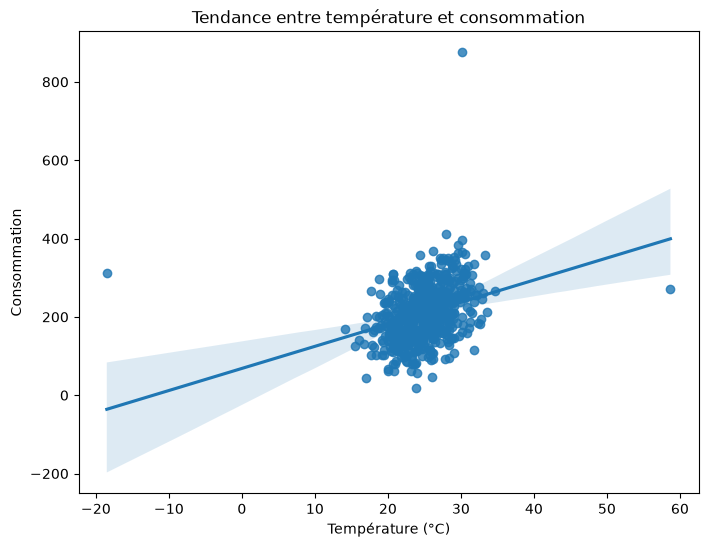

In [32]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x="temperature", y="consommation")
plt.title("Tendance entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()

# Partie 8 – Régression avec lmplot() 

## Etudier graphiquement une tendance entre température et consommation par bâtiment 

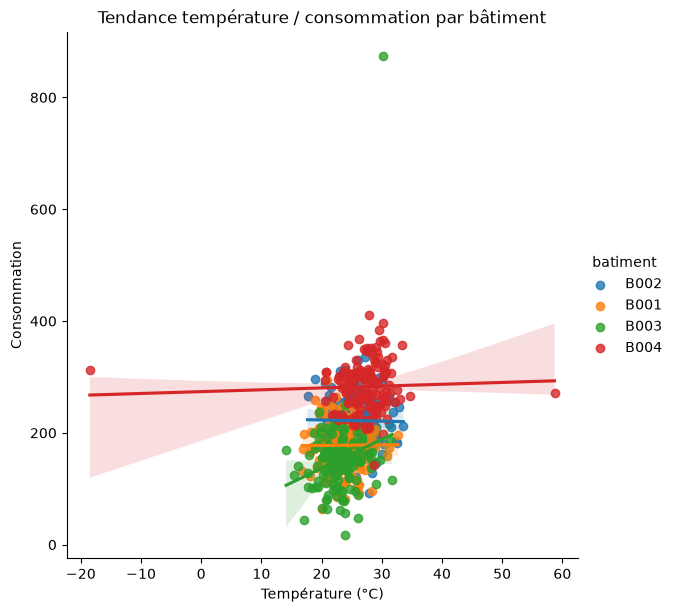

In [37]:
sns.lmplot(data=df, x="temperature", y="consommation", hue="batiment", height=6 )
plt.title("Tendance température / consommation par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()

# Partie 9 – Corrélations 

## 1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et consommation.

In [39]:
variables = ["temperature", "humidite", "pression", "consommation"]
matrice_corr = df[variables].corr()

## 2) Afficher la matrice de corrélation obtenue avec Pandas 

In [40]:
print("La corrélation entre les variabes est de: ", matrice_corr)

La corrélation entre les variabes est de:                temperature  humidite  pression  consommation
temperature      1.000000 -0.006126  0.061283      0.317048
humidite        -0.006126  1.000000  0.045242     -0.046061
pression         0.061283  0.045242  1.000000      0.056051
consommation     0.317048 -0.046061  0.056051      1.000000


3) Afficher le heatmap de la corrélation pour identifier : a) les corrélations positives ;  b) les corrélations négatives ;  c) les corrélations proches de zéro ;  d) les variables qui semblent fortement liées. 

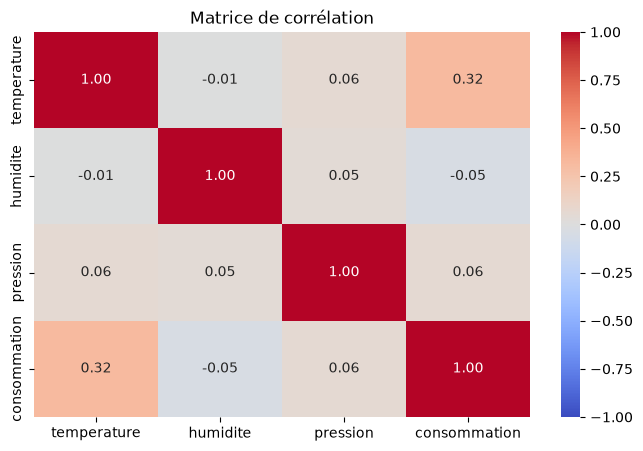

In [42]:
plt.figure(figsize=(8,5))
sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

**Commentaire sur la matrice de corrélation obtenue**

En regardant les valeurs hors diagonale de le heatmap :

**a) Corrélations positives**
Toutes les relations hors diagonale sont soit positives, soit quasi nulles. Il n'y a aucune corrélation négative marquée dans ce dataset. Les couleurs orangées/rouges les plus visibles concernent : 
température ↔ consommation : 0.32 — la relation la plus forte du tableau
pression avec les autres variables (0.05 à 0.06) — très faiblement positive
température ↔ pression : 0.06 — quasi nulle

**b) Corrélations négatives**
Il n'y en a pratiquement pas dans ce jeu de données. Les deux seules valeurs négatives sont infimes :

humidité ↔ consommation : -0.05
température ↔ humidité : -0.01

Ce sont des valeurs si proches de zéro qu'on ne peut pas vraiment parler de relation négative réelle — c'est du bruit statistique plus qu'une tendance.

**c) Corrélations proches de zéro**
La grande majorité des paires sont ici : température/humidité (-0.01), température/pression (0.06), humidité/pression (0.05), humidité/consommation (-0.05), pression/consommation (0.06). Ces cases apparaissent en gris très clair sur le heatmap, ce qui confirme visuellement l'absence de relation linéaire entre ces variables.

d) Variables qui semblent fortement liées
Aucune paire n'est fortement liée au sens strict (on serait plutôt à partir de 0.5-0.7 en valeur absolue pour parler de corrélation forte). Cela dit, en relatif, la seule paire qui se démarque nettement des autres est température et consommation avec 0.32 — visible sur le graphique par la case nettement plus orangée que toutes les autres cases hors diagonale.

Interprétation d'ensemble

Ce que révèle cette matrice : la température est le principal facteur influençant la consommation énergétique dans ce dataset (même si la relation reste modérée à 0.32, pas très forte) — ce qui confirme et quantifie ce que tu avais observé visuellement dans les Parties 6, 7 et 8 avec le scatterplot et les droites de régression.

En revanche, l'humidité et la pression ne semblent jouer aucun rôle linéaire significatif ni sur la consommation, ni entre elles, ni avec la température. Deux limites à noter dans ton notebook :

Une corrélation de 0.32 est réelle mais modeste — la température seule n'explique qu'une partie limitée de la variation de consommation ; d'autres facteurs (heure de la journée, occupation du bâtiment, équipements...) jouent probablement un rôle plus important.
Comme évoqué en Partie 7, .corr() ne capture que les relations linéaires — humidité et pression pourraient avoir un effet réel mais non-linéaire sur la consommation, invisible ici. Le pairplot de la Partie 10 permettra de vérifier ça visuellement.

# Partie 10 – Analyse multivariée avec pairplot()

## En considérant la température, l’humidité, la pression et la consommation, réaliser un graphique qui affiche simultanément les distributions individuelles et les scatter plots entre variables. 

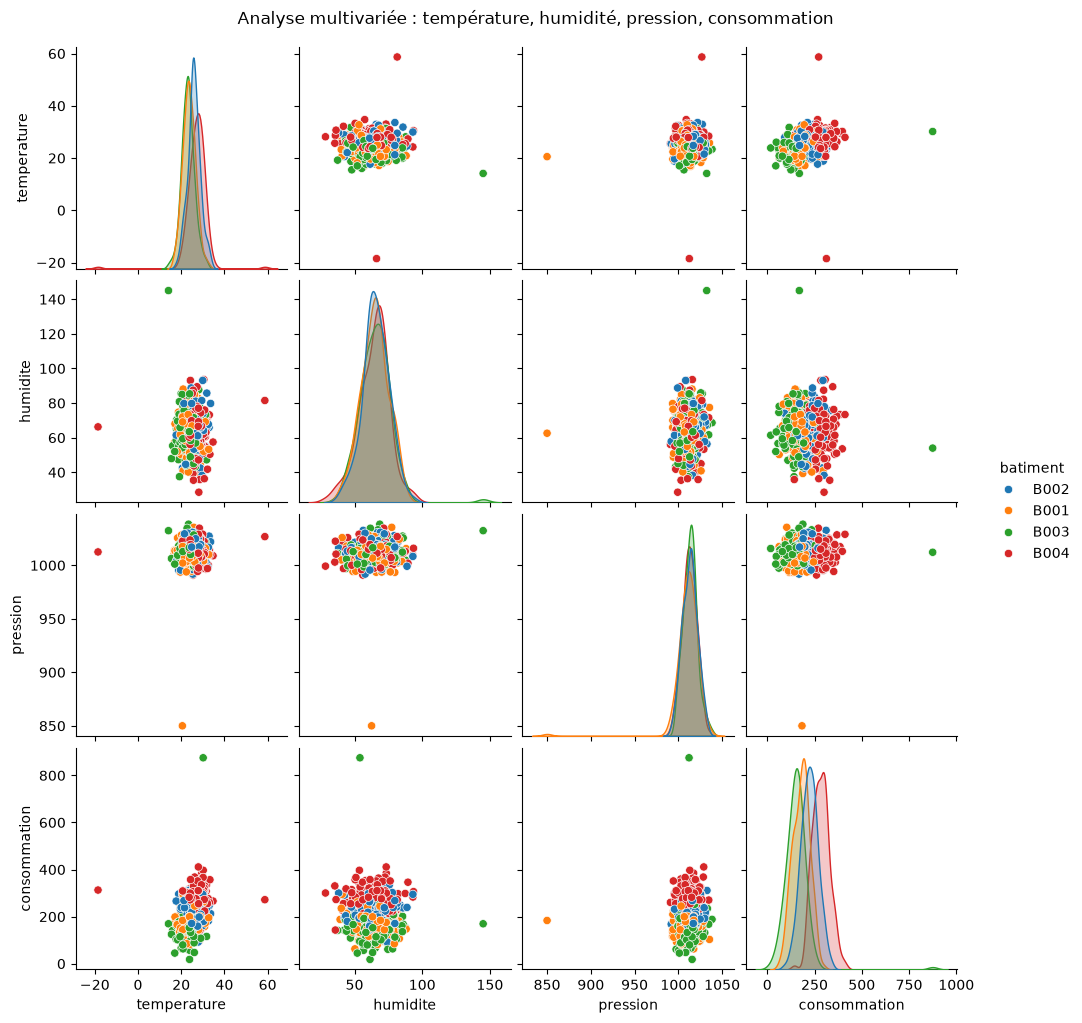

In [43]:
variables = ["temperature", "humidite", "pression", "consommation"]

sns.pairplot(df[variables + ["batiment"]], hue="batiment", diag_kind="kde", height=2.5)
plt.suptitle("Analyse multivariée : température, humidité, pression, consommation", y=1.02)
plt.show()

# Partie 11 : Sauvegarde des graphiques

## Sauvegarder les graphiques dans le sous-dossier exports

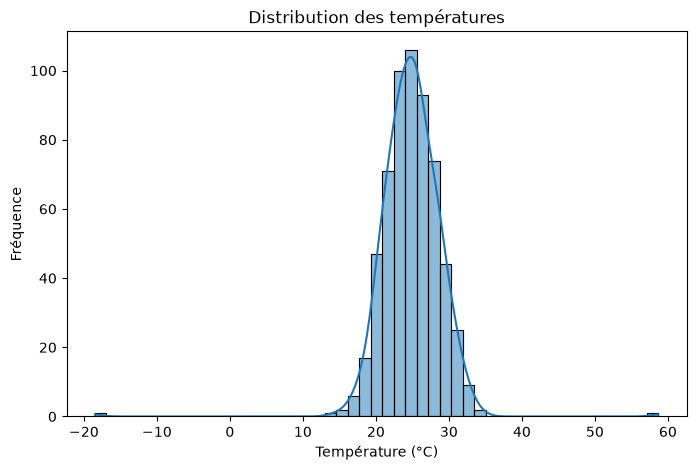

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="temperature", kde=True)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")

# Sauvegarde AVANT le show()
plt.savefig("../exports/temperatures.png", dpi=300, bbox_inches="tight")
plt.savefig("../exports/temperatures.pdf", bbox_inches="tight")

plt.show()

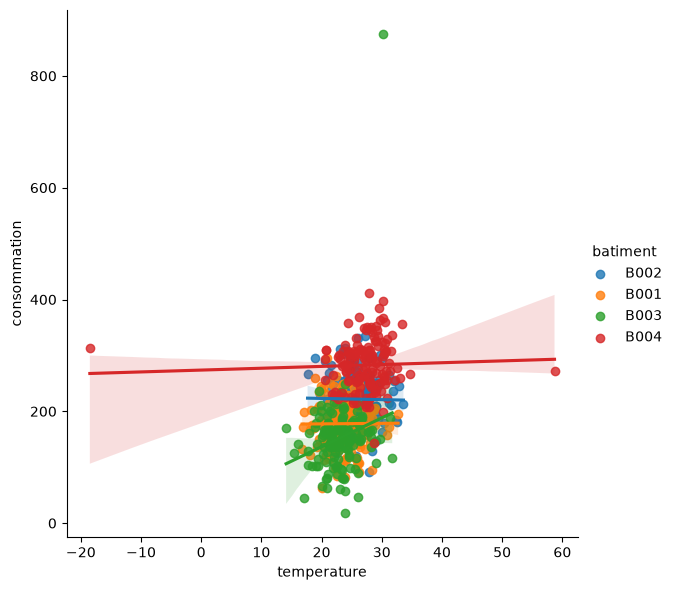

In [48]:
g = sns.lmplot(data=df, x="temperature", y="consommation", hue="batiment", height=6)
g.savefig("../exports/lmplot.pdf", dpi=300, bbox_inches="tight")
g.savefig("../exports/lmplots.png", dpi=300, bbox_inches="tight")
plt.show()

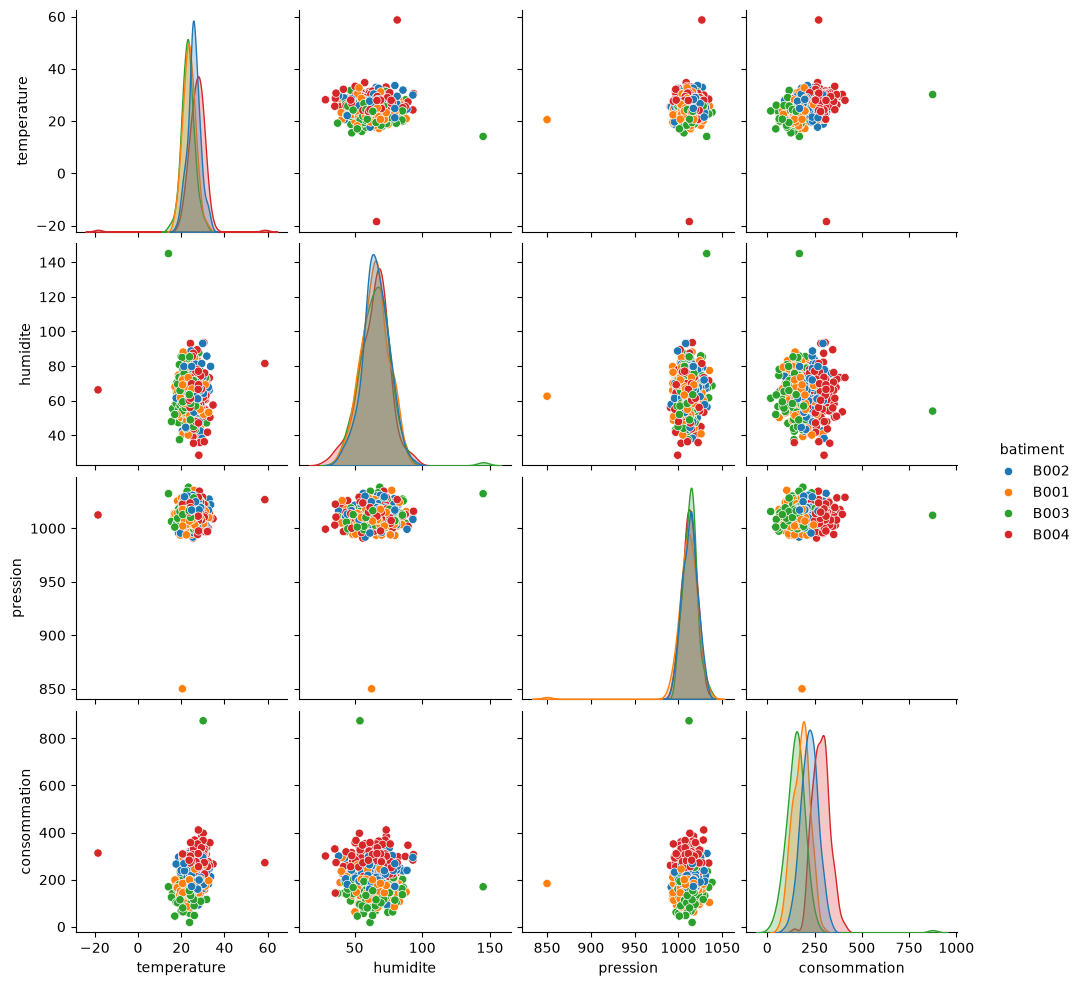

In [49]:
g = sns.pairplot(df[variables + ["batiment"]], hue="batiment", diag_kind="kde", height=2.5)
g.savefig("../exports/pairplot.png", dpi=300, bbox_inches="tight")
g.savefig("../exports/pairplot.pdf", dpi=300, bbox_inches="tight")

plt.show()